In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2019, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #1872: 1630
Sim #7102: 1610
Sim #4089: 1580
Sim #2336: 1580
Sim #7555: 1570

BOTTOM 5 SCORES
Sim #7147: 250
Sim #8866: 260
Sim #2167: 270
Sim #1285: 280
Sim #704: 280

AVERAGE SCORE: 729.49


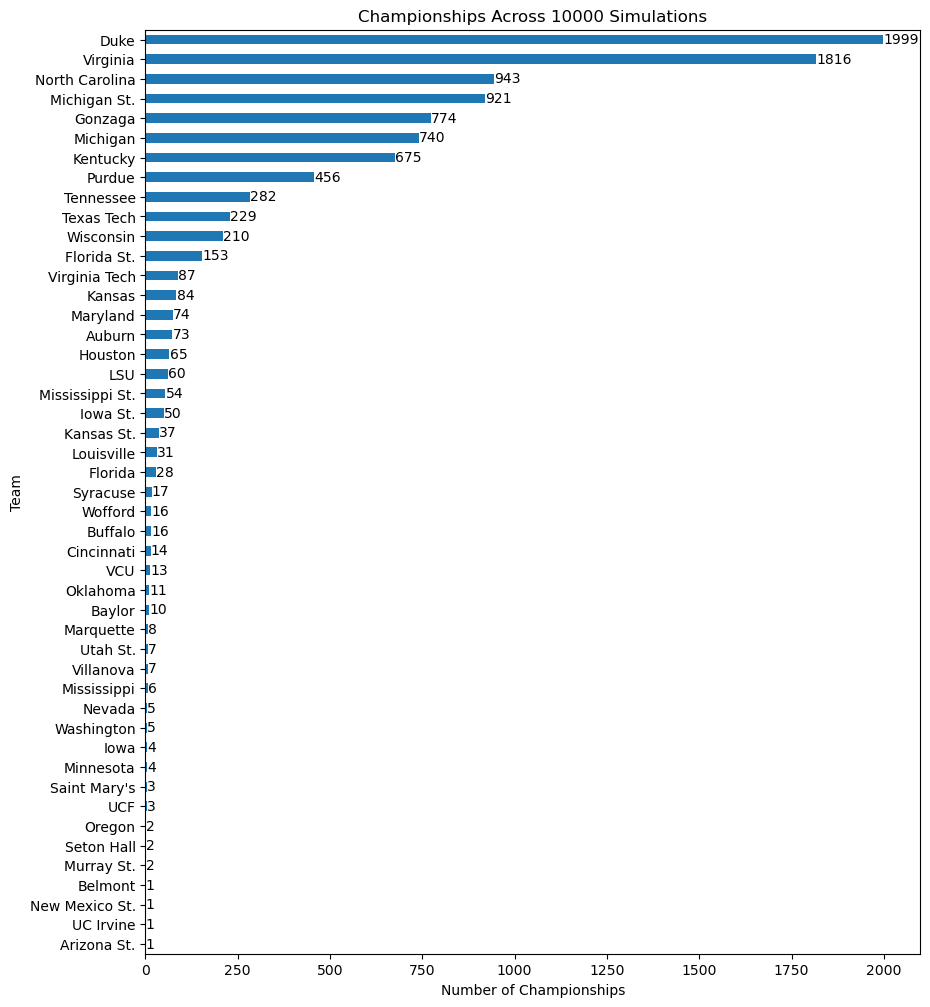

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Duke              1999 --> 19.99%          Syracuse           17 --> 0.17%            UC Irvine           1 --> 0.01%         
Virginia          1816 --> 18.16%          Buffalo            16 --> 0.16%            Ohio St.            0 --> 0.0%          
North Carolina    943 --> 9.43%            Wofford            16 --> 0.16%            Liberty             0 --> 0.0%          
Michigan St.      921 --> 9.21%            Cincinnati         14 --> 0.14%            Northeastern        0 --> 0.0%          
Gonzaga           774 --> 7.74%            VCU                13 --> 0.13%            Vermont             0 --> 0.0%          
Michigan          740 --> 7.4%             Oklahoma           11 --> 0.11%            Saint Louis         0 --> 0.0%          
Kentucky          675 --> 6.75%            Baylor             10 --> 0.1%             Georgia St.         0 --> 0.0%          
Purdue            456 --> 4.56%            Marquette           8 -

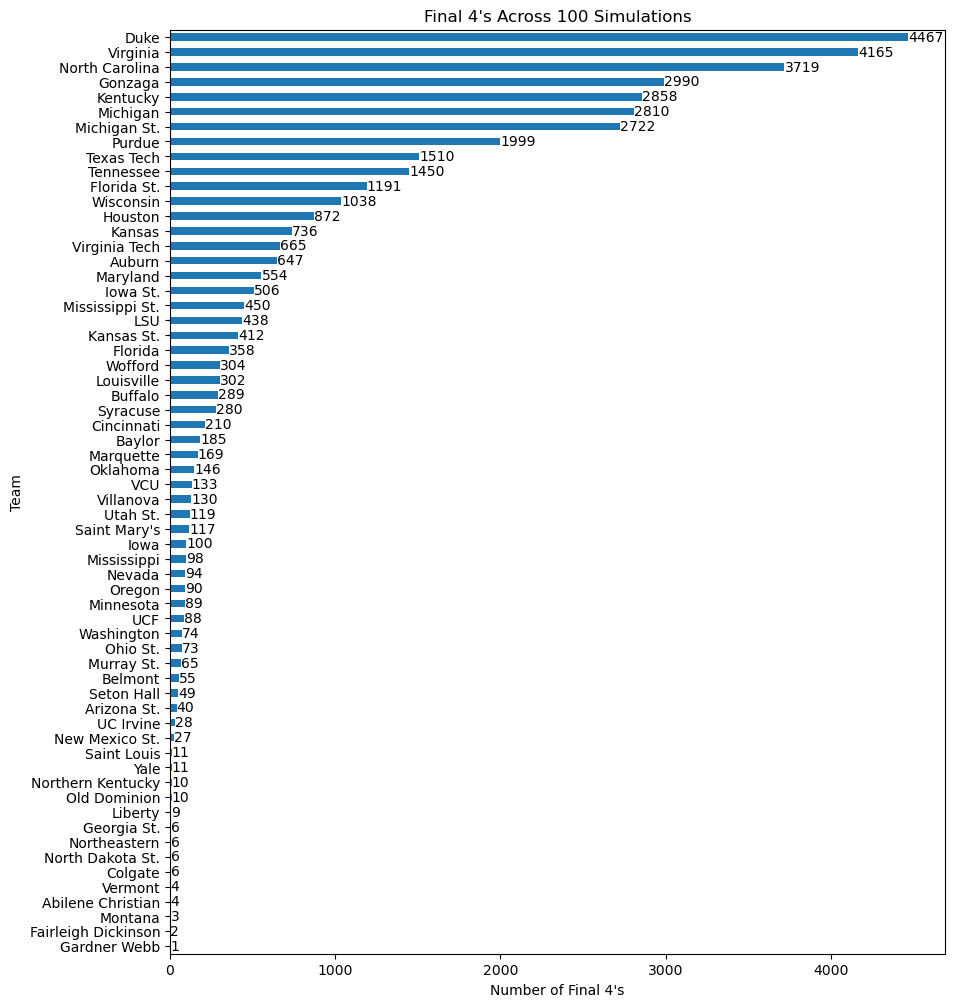

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Duke              4467 --> 44.67%          Louisville        302 --> 3.02%            UC Irvine          28 --> 0.28%         
Virginia          4165 --> 41.65%          Buffalo           289 --> 2.89%            New Mexico St.     27 --> 0.27%         
North Carolina    3719 --> 37.19%          Syracuse          280 --> 2.8%             Saint Louis        11 --> 0.11%         
Gonzaga           2990 --> 29.9%           Cincinnati        210 --> 2.1%             Yale               11 --> 0.11%         
Kentucky          2858 --> 28.58%          Baylor            185 --> 1.85%            Old Dominion       10 --> 0.1%          
Michigan          2810 --> 28.1%           Marquette         169 --> 1.69%            Northern Kentucky  10 --> 0.1%          
Michigan St.      2722 --> 27.22%          Oklahoma          146 --> 1.46%            Liberty             9 --> 0.09%         
Purdue            1999 --> 19.99%          VCU               133 --> 1

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Duke              6248 --> 62.48%          Buffalo           892 --> 8.92%            New Mexico St.    146 --> 1.46%         
North Carolina    5841 --> 58.41%          Florida           883 --> 8.83%            UC Irvine         141 --> 1.41%         
Virginia          5728 --> 57.28%          Syracuse          808 --> 8.08%            Old Dominion       81 --> 0.81%         
Michigan St.      5259 --> 52.59%          Cincinnati        799 --> 7.99%            Saint Louis        74 --> 0.74%         
Kentucky          4900 --> 49.0%           Marquette         598 --> 5.98%            Northern Kentucky  73 --> 0.73%         
Gonzaga           4845 --> 48.45%          Baylor            521 --> 5.21%            Yale               56 --> 0.56%         
Michigan          4712 --> 47.12%          Saint Mary's      493 --> 4.93%            Vermont            55 --> 0.55%         
Purdue            4342 --> 43.42%          Oklahoma          458 --> 4

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Duke              7743 --> 77.43%          Marquette         2229 --> 22.29%          New Mexico St.    747 --> 7.47%         
North Carolina    7711 --> 77.11%          Wofford           1990 --> 19.9%           UC Irvine         724 --> 7.24%         
Virginia          7697 --> 76.97%          Florida           1918 --> 19.18%          Saint Louis       481 --> 4.81%         
Michigan St.      7097 --> 70.97%          Louisville        1878 --> 18.78%          Northern Kentucky 433 --> 4.33%         
Kentucky          6977 --> 69.77%          Syracuse          1794 --> 17.94%          Yale              400 --> 4.0%          
Purdue            6932 --> 69.32%          Saint Mary's      1442 --> 14.42%          Vermont           398 --> 3.98%         
Gonzaga           6803 --> 68.03%          Iowa              1278 --> 12.78%          Old Dominion      389 --> 3.89%         
Michigan          6789 --> 67.89%          Oklahoma          1249 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
592873,9264,3,Montana,15,0,5,100.0,N/A,11.862,Michigan,18.351,Florida,15.335,Texas Tech,13.956,Florida St.,9.630,Duke,10.032,North Carolina,0.004
268204,4191,3,Northern Kentucky,14,0,5,100.0,N/A,19.515,Texas Tech,18.811,Buffalo,22.250,Florida,10.238,Gonzaga,8.661,Duke,10.250,Virginia,0.007
76963,1203,3,Fairleigh Dickinson,16,0,5,100.0,N/A,9.777,Gonzaga,16.060,Syracuse,28.338,Vermont,16.794,Nevada,11.875,Michigan St.,9.226,Purdue,0.008
390715,6105,4,Saint Louis,13,0,5,100.0,N/A,19.098,Virginia Tech,21.345,Mississippi St.,9.728,Duke,20.385,LSU,11.400,Michigan,11.819,Virginia,0.008
587643,9182,4,Saint Louis,13,0,5,100.0,N/A,19.098,Virginia Tech,21.345,Mississippi St.,9.728,Duke,16.792,Maryland,17.089,Florida,11.819,Virginia,0.010
112332,1756,1,Seton Hall,10,0,6,100.0,N/A,36.318,Wofford,16.466,Kentucky,26.138,Houston,25.159,Kansas,16.158,Virginia,17.364,Michigan St.,0.011
45527,712,2,Old Dominion,14,0,5,100.0,N/A,14.610,Purdue,32.137,Villanova,20.228,Tennessee,11.541,Virginia,12.439,North Carolina,10.624,Duke,0.012
449096,7018,1,New Mexico St.,12,0,6,100.0,N/A,20.990,Auburn,28.183,Kansas,13.941,North Carolina,44.910,Seton Hall,14.924,Purdue,24.555,Texas Tech,0.014
5262,83,1,Washington,9,1,6,100.0,N/A,45.840,Utah St.,14.320,North Carolina,31.764,Auburn,29.807,Iowa St.,13.434,Virginia,18.234,Florida St.,0.015
98347,1537,3,Nevada,7,0,6,100.0,N/A,38.307,Florida,20.495,Michigan,64.677,Arizona St.,16.284,Gonzaga,14.060,Duke,12.954,Virginia,0.015


In [11]:
df[df["sim_num"] == 1872].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
119774,1872,2,Virginia,1,6,6,100.0,N/A,91.068,Gardner Webb,84.636,Mississippi,86.365,UC Irvine,68.450,Purdue,76.302,Auburn,70.558,Texas Tech,24.531
119790,1872,3,Texas Tech,3,5,5,100.0,N/A,80.485,Northern Kentucky,78.188,Arizona St.,40.381,Michigan,36.656,Gonzaga,25.774,Duke,29.442,Virginia,1.694
119745,1872,1,Auburn,5,4,4,100.0,N/A,79.010,New Mexico St.,46.969,Kansas,26.574,North Carolina,54.184,Iowa St.,23.698,Virginia,0.000,N/A,4.077
119794,1872,4,Duke,1,3,4,100.0,N/A,89.435,North Dakota St.,86.859,VCU,79.216,Virginia Tech,62.087,Michigan St.,74.226,Texas Tech,0.000,N/A,9.847
119769,1872,2,Purdue,3,3,3,100.0,N/A,85.390,Old Dominion,79.389,Villanova,53.913,Tennessee,31.550,Virginia,0.000,N/A,0.000,N/A,25.017
119782,1872,3,Gonzaga,1,3,3,100.0,N/A,90.223,Fairleigh Dickinson,79.868,Baylor,62.631,Florida St.,63.344,Texas Tech,0.000,N/A,0.000,N/A,16.543
119799,1872,4,Michigan St.,2,4,3,100.0,N/A,89.633,Bradley,79.944,Minnesota,83.414,Belmont,37.913,Duke,0.000,N/A,0.000,N/A,37.110
119749,1872,1,Iowa St.,6,0,3,100.0,N/A,69.057,Ohio St.,89.698,Georgia St.,58.141,Wofford,45.816,Auburn,0.000,N/A,0.000,N/A,19.514
119781,1872,3,Florida St.,4,2,2,100.0,N/A,83.985,Vermont,73.134,Marquette,37.369,Gonzaga,0.000,N/A,0.000,N/A,0.000,N/A,38.469
119753,1872,1,North Carolina,1,2,2,100.0,N/A,89.417,Iona,85.680,Washington,73.426,Auburn,0.000,N/A,0.000,N/A,0.000,N/A,20.359


In [12]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  148


In [14]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  11


In [19]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  15
[2336 2588 3464 3607 4523 5326 5411 5895 6264 6932 7022 8353 8909 9548
 9999]


In [24]:
df[df["sim_num"] == 6264].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
400882,6264,4,Duke,1,3,6,100.0,N/A,89.435,North Dakota St.,86.859,VCU,79.216,Virginia Tech,62.087,Michigan St.,74.226,Texas Tech,70.211,Purdue,19.911
400857,6264,2,Purdue,3,3,5,100.0,N/A,85.390,Old Dominion,81.267,Saint Mary's,53.913,Tennessee,31.550,Virginia,65.149,Auburn,29.789,Duke,5.399
400833,6264,1,Auburn,5,4,4,100.0,N/A,79.010,New Mexico St.,46.969,Kansas,68.763,Utah St.,29.679,Kentucky,34.851,Purdue,0.000,N/A,4.934
400878,6264,3,Texas Tech,3,5,4,100.0,N/A,80.485,Northern Kentucky,68.139,Buffalo,75.032,Nevada,36.656,Gonzaga,25.774,Duke,0.000,N/A,11.196
400839,6264,1,Kentucky,2,3,3,100.0,N/A,89.616,Abilene Christian,75.718,Wofford,66.380,Houston,70.321,Auburn,0.000,N/A,0.000,N/A,13.368
400870,6264,3,Gonzaga,1,3,3,100.0,N/A,90.223,Fairleigh Dickinson,79.868,Baylor,62.631,Florida St.,63.344,Texas Tech,0.000,N/A,0.000,N/A,16.543
400862,6264,2,Virginia,1,6,3,100.0,N/A,91.068,Gardner Webb,84.018,Oklahoma,85.007,Oregon,68.450,Purdue,0.000,N/A,0.000,N/A,20.521
400887,6264,4,Michigan St.,2,4,3,100.0,N/A,89.633,Bradley,79.944,Minnesota,71.359,LSU,37.913,Duke,0.000,N/A,0.000,N/A,31.747
400869,6264,3,Florida St.,4,2,2,100.0,N/A,83.985,Vermont,75.135,Murray St.,37.369,Gonzaga,0.000,N/A,0.000,N/A,0.000,N/A,39.521
400859,6264,2,Tennessee,2,2,2,100.0,N/A,85.993,Colgate,68.380,Cincinnati,46.087,Purdue,0.000,N/A,0.000,N/A,0.000,N/A,31.702


In [25]:
scores[6263]

990

In [16]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [17]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [26]:
df[(df["TEAM"] == "Auburn") & (df["R32_opp"] == "Kansas") & (df["S16_opp"] == "North Carolina") & (df["E8_opp"] == "Kentucky") & (df["F4_opp"] == "Virginia")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
14209,223,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
31105,487,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
64897,1015,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
67201,1051,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
75585,1182,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
113025,1767,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
132481,2071,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
133313,2084,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
142465,2227,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233
149441,2336,1,Auburn,5,4,4,100.0,N/A,79.01,New Mexico St.,46.969,Kansas,26.574,North Carolina,29.679,Kentucky,23.698,Virginia,0.000,N/A,2.233


In [27]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
431391,6741,2,Wisconsin,5,0,6,100.0,N/A,74.348,Oregon,78.193,UC Irvine,30.041,Virginia,47.020,Tennessee,43.572,North Carolina,60.158,Florida St.,2.152
431397,6741,3,Florida St.,4,2,5,100.0,N/A,83.985,Vermont,73.134,Marquette,37.369,Gonzaga,61.358,Florida,52.985,LSU,39.842,Wisconsin,4.489
431413,6741,4,LSU,3,2,4,100.0,N/A,82.126,Yale,42.422,Maryland,67.494,Minnesota,80.352,Liberty,47.015,Florida St.,0.000,N/A,10.011
431369,6741,1,North Carolina,1,2,4,100.0,N/A,89.417,Iona,85.696,Utah St.,75.661,Kansas,72.139,Houston,56.428,Wisconsin,0.000,N/A,18.223
431387,6741,2,Tennessee,2,2,3,100.0,N/A,85.993,Colgate,68.380,Cincinnati,77.312,Villanova,52.980,Wisconsin,0.000,N/A,0.000,N/A,21.376
431363,6741,1,Houston,3,2,3,100.0,N/A,84.189,Georgia St.,55.135,Iowa St.,73.862,Seton Hall,27.861,North Carolina,0.000,N/A,0.000,N/A,24.733
431396,6741,3,Florida,10,1,3,100.0,N/A,61.693,Nevada,81.649,Montana,57.024,Buffalo,38.642,Florida St.,0.000,N/A,0.000,N/A,17.625
431411,6741,4,Liberty,12,1,3,100.0,N/A,18.543,Mississippi St.,12.235,Virginia Tech,10.807,Duke,19.648,LSU,0.000,N/A,0.000,N/A,0.197
431390,6741,2,Virginia,1,6,2,100.0,N/A,91.068,Gardner Webb,84.018,Oklahoma,69.959,Wisconsin,0.000,N/A,0.000,N/A,0.000,N/A,22.986
431389,6741,2,Villanova,6,1,2,100.0,N/A,46.715,Saint Mary's,67.863,Old Dominion,22.688,Tennessee,0.000,N/A,0.000,N/A,0.000,N/A,24.509


In [31]:
df[(df["TEAM"] == "Wofford") & (df["E8_opp"] == "Kansas")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
20431,320,1,Wofford,7,1,3,100.0,N/A,63.682,Seton Hall,24.282,Kentucky,85.369,Georgia St.,40.027,Kansas,0.000,N/A,0.0,N/A,7.917
27791,435,1,Wofford,7,1,3,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,38.314,Houston,40.027,Kansas,0.000,N/A,0.0,N/A,12.782
28495,446,1,Wofford,7,1,4,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,38.314,Houston,40.027,Kansas,19.007,Virginia,0.0,N/A,6.910
30543,478,1,Wofford,7,1,4,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,66.203,Ohio St.,40.027,Kansas,19.007,Virginia,0.0,N/A,11.939
30735,481,1,Wofford,7,1,3,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,38.314,Houston,40.027,Kansas,0.000,N/A,0.0,N/A,12.782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623567,9744,1,Wofford,7,1,3,100.0,N/A,63.682,Seton Hall,24.282,Kentucky,41.859,Iowa St.,40.027,Kansas,0.000,N/A,0.0,N/A,3.882
626959,9797,1,Wofford,7,1,4,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,41.859,Iowa St.,40.027,Kansas,19.007,Virginia,0.0,N/A,7.549
628687,9824,1,Wofford,7,1,3,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,38.314,Houston,40.027,Kansas,0.000,N/A,0.0,N/A,12.782
633807,9904,1,Wofford,7,1,4,100.0,N/A,63.682,Seton Hall,87.353,Abilene Christian,66.203,Ohio St.,40.027,Kansas,25.210,Purdue,0.0,N/A,11.025


In [18]:
df.to_csv("../../data/2019_10000sims0.csv")